In [ ]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [1]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
sys.path.insert(0, dir1)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer
from sklearn.feature_selection import VarianceThreshold

from MIMICUtil import *

/home/idies/miniconda3/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [11]:
from econml.dml import CausalForestDML, SparseLinearDML, LinearDML, DML
from econml.orf import DMLOrthoForest
from econml.dr import LinearDRLearner
myTreatment = 'hypothermia'
myTreatmentColumn = myTreatment
myPredicted = 'death_at_disch'
myPredictorsDf, X_train_no_group, X_test_no_group, T_train, T_test, y_train, y_test =  \
                    getTrainTestFunctions(aPredictedColumn = myPredicted, 
                                            aTreatmentColumn = myTreatment, aTreatmentSplit = True, aSkipTemp = True, 
                                            aTestSize=.3) 
causal_forest = CausalForestDML(
    model_y= XGBClassifier(max_depth=25, n_estimators=100),  
    model_t= XGBClassifier(max_depth=10, n_estimators=20),    
    discrete_treatment=True,           
    discrete_outcome=True,
    verbose=2,
    n_jobs=-1
)

In [12]:
def getCovariatePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = PCA(0.99)
        )

def getVariancePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = VarianceThreshold(0.01)
        )
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=50)
    myImputer.set_output(transform="pandas")
    myCovariates = getCovariatePreprocessor([])
    myCovariates.set_output(transform="pandas")
    myVariance = getVariancePreprocessor([])
    myVariance.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor),  ('variance', myVariance), ('imputer', myImputer), ('covariates', myCovariates)]

In [13]:
X_train_no_group = X_train_no_group.loc[:, X_train_no_group.isnull().mean() < 0.9]
X_test_no_group = X_test_no_group[X_train_no_group.columns]

In [14]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train_no_group))

In [15]:
myNewXTrain = pd.DataFrame(myPipeline.fit_transform(X_train_no_group), columns = myPipeline.get_feature_names_out())
myNewXTest = pd.DataFrame(myPipeline.transform(X_test_no_group), columns = myPipeline.get_feature_names_out())


In [16]:
causal_forest.fit(y_train, T_train, X=myNewXTrain, cache_values=True)
print(causal_forest.score(y_train, T_train, X=myNewXTrain))

CATE_pred = causal_forest.effect(myNewXTrain)

print(f'Feature importances {causal_forest.feature_importances_}')

print("Predicted CATE for test data:", CATE_pred[:10])

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s


0.06252500120454277
Feature importances [2.49775691e-03 5.72058736e-03 1.37766660e-02 4.20862127e-03
 8.70941867e-03 9.43805388e-04 1.24014314e-03 2.06584789e-02
 1.71888882e-03 3.52823775e-03 9.74010557e-04 1.80909339e-03
 3.78954889e-03 1.90142594e-03 2.50981787e-03 9.41020171e-03
 1.14475967e-03 2.99770971e-04 1.29091385e-02 3.46567442e-04
 5.05375181e-03 1.31939628e-02 9.69105896e-04 6.85738905e-04
 2.02363222e-04 3.48888256e-03 6.31173831e-03 5.03855806e-04
 7.08141871e-03 8.59879119e-05 1.53954331e-03 3.17942219e-03
 1.34235621e-03 2.62662405e-04 5.29032516e-03 2.11028730e-03
 3.24066935e-03 7.21714717e-03 7.18627417e-03 1.59544468e-03
 1.97634942e-03 8.78207214e-03 9.28526365e-03 5.22879755e-03
 1.05427238e-02 3.58004662e-03 4.21238514e-03 4.02748885e-06
 7.40740087e-04 8.22309142e-03 2.65455833e-03 1.26267253e-03
 5.04876012e-03 6.72587797e-04 8.12455162e-04 1.29396482e-03
 2.24992406e-03 1.01105917e-02 6.58808840e-03 0.00000000e+00
 1.58040256e-03 5.06112125e-03 1.86542557e-03

[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.0s finished


In [17]:
causal_forest.summary()

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s


Population summary of CATE predictions on Training Data


[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  12 out of  25 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=20)]: Done  25 out of  25 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=20)]: Done  25 out of  25 | elapsed:    0.0s finished


<class 'econml.utilities.Summary'>
"""
               Uncertainty of Mean Point Estimate               
================================================================
mean_point stderr_mean zstat  pvalue ci_mean_lower ci_mean_upper
----------------------------------------------------------------
    -0.003       0.109 -0.032  0.975        -0.216         0.209
      Distribution of Point Estimate     
=========================================
std_point pct_point_lower pct_point_upper
-----------------------------------------
    0.047          -0.106           0.094
     Total Variance of Point Estimate     
==========================================
stderr_point ci_point_lower ci_point_upper
------------------------------------------
       0.118         -0.241          0.232
       Doubly Robust ATE on Training Data Results       
========================================================
    point_estimate stderr zstat pvalue ci_lower ci_upper
--------------------------------------------------------
ATE          0.023  0.125 0.187  0.852   -0.222    0.269
    Doubly Robust ATT(T=0) on Training Data Results     
========================================================
    point_estimate stderr zstat pvalue ci_lower ci_upper
--------------------------------------------------------
ATT          0.103  0.115 0.894  0.371   -0.122    0.328
     Doubly Robust ATT(T=1) on Training Data Results     
=========================================================
    point_estimate stderr zstat  pvalue ci_lower ci_upper
---------------------------------------------------------
ATT          -0.07  0.237 -0.295  0.768   -0.535    0.395
---------------------------------------------------------

Note: The stderr_mean is a conservative upper bound.
"""

Optimization terminated successfully.
         Current function value: 0.649035
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.647077
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 1.6718701282179609
p-value: 0.19600823335241124
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:         death_at_disch   No. Observations:                  427
Model:                          Logit   Df Residuals:                      424
Method:                           MLE   Df Model:                            2
Date:                Sun, 11 May 2025   Pseudo R-squ.:                0.005222
Time:                        17:50:05   Log-Likelihood:                -277.14
converged:                       True   LL-Null:                       -278.59
Covariance Type:            nonrobust   LLR p-value:                    0.2335
                     

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.0s finished


0.19600823335241124

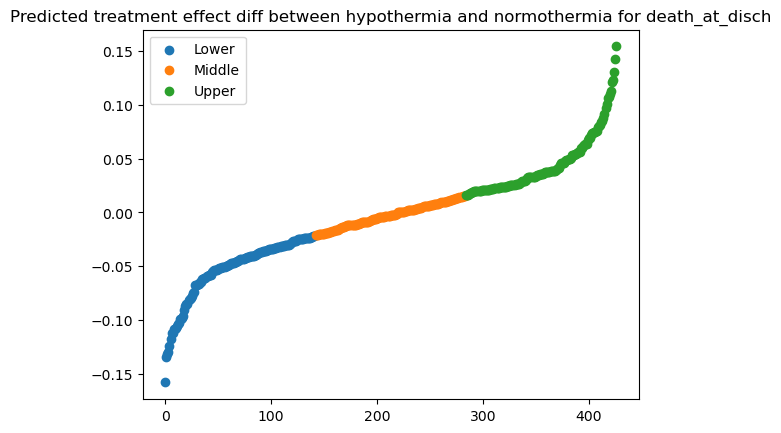

In [18]:
# myNewXTrain = pd.DataFrame(myPipeline.transform(X_train_no_group), columns = myPipeline.get_feature_names_out())
CATE_pred = causal_forest.effect(myNewXTrain)

myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = CATE_pred[:, 0]
lower_third, upper_third, _ = getPredictedThirds(myNewDf)
plotPredictedTreatmentEffect(myNewDf, myPredicted)
# myNewDf['predicted_effect_group'] = (myNewDf['predicted_effect'] > 0).astype(str)

X_train_new = X_train_no_group.copy().reset_index()
X_train_new[myTreatment] = T_train.reset_index()[myTreatment]
y_train_df = pd.DataFrame()
y_train_df[myPredicted] = y_train.reset_index()[myPredicted]
getTreatmentEffectDiffDataFrame(X_train_new, y_train_df, myNewDf, myPredicted, myTreatment, False)

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  12 out of  25 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=20)]: Done  25 out of  25 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=20)]: Done  25 out of  25 | elapsed:    0.0s finished


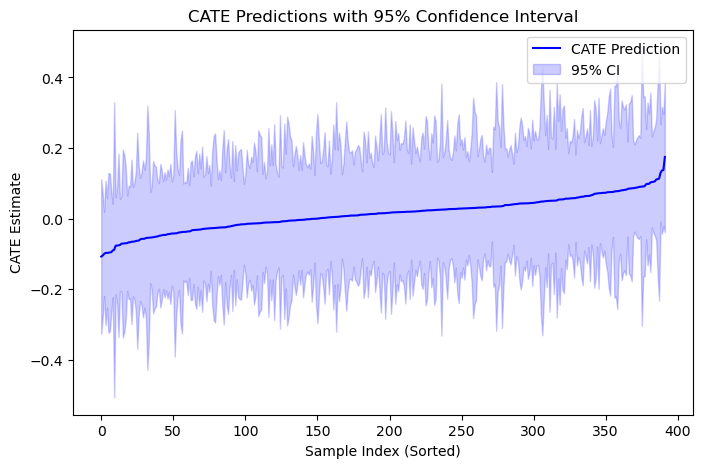

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Compute CATE prediction intervals
CATE_pred = causal_forest.effect(myNewXTrain)

cate_lower, cate_upper = causal_forest.effect_interval(myNewXTrain, alpha=0.05)

# Ensure arrays are 1D NumPy arrays
CATE_pred = np.array(CATE_pred).flatten()
cate_lower = np.array(cate_lower).flatten()
cate_upper = np.array(cate_upper).flatten()

# Sort values for a cleaner plot
sorted_idx = np.argsort(CATE_pred)
cate_pred_sorted = CATE_pred[sorted_idx]
cate_lower_sorted = cate_lower[sorted_idx]
cate_upper_sorted = cate_upper[sorted_idx]

# Create x-axis index
x = np.arange(len(cate_pred_sorted))

# Plot CATE predictions
plt.figure(figsize=(8, 5))
plt.plot(x, cate_pred_sorted, label='CATE Prediction', color='blue')

# Fill confidence interval
plt.fill_between(x, cate_lower_sorted, cate_upper_sorted, 
                 color='blue', alpha=0.2, label='95% CI')

# Labels and title
plt.xlabel("Sample Index (Sorted)")
plt.ylabel("CATE Estimate")
plt.title("CATE Predictions with 95% Confidence Interval")
plt.legend()
plt.show()


Optimization terminated successfully.
         Current function value: 0.635411
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.634173
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 1.0520993414195345
p-value: 0.3050240846757174
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:         death_at_disch   No. Observations:                  425
Model:                          Logit   Df Residuals:                      422
Method:                           MLE   Df Model:                            2
Date:                Sun, 27 Apr 2025   Pseudo R-squ.:                0.009975
Time:                        19:48:13   Log-Likelihood:                -270.05
converged:                       True   LL-Null:                       -272.77
Covariance Type:            nonrobust   LLR p-value:                   0.06582
                      

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.0s finished


0.3050240846757174

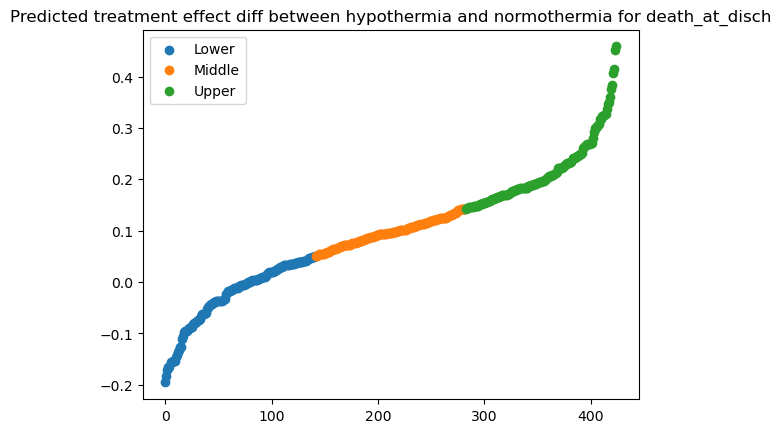

In [30]:
# myNewXTest = myPipeline.transform(X_test_no_group)
CATE_pred = causal_forest.effect(myNewXTest)

myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = CATE_pred[:, 0]
lower_third, upper_third, _ = getPredictedThirds(myNewDf)
plotPredictedTreatmentEffect(myNewDf, myPredicted)
myNewDf['predicted_effect_group'] = (myNewDf['predicted_effect'] > 0).astype(str)


X_test_new = X_test_no_group.copy().reset_index()
X_test_new[myTreatment] = T_test.reset_index()[myTreatment]
y_test_df = pd.DataFrame()
y_test_df[myPredicted] = y_test.reset_index()[myPredicted]
getTreatmentEffectDiffDataFrame(X_test_new, y_test_df, myNewDf, myPredicted, myTreatment, False)